In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA_PATH = "../data/raw/FinanKu_Data_All.csv"

df = pd.read_csv(DATA_PATH)

# Duplicate Records
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


In [3]:
# Invalid Values
df["Age"].describe()

df["Age"].sort_values().head()
df["Age"].sort_values().tail()

5037    70
504     70
6047    70
5090    70
1323    70
Name: Age, dtype: int64

In [4]:
# Income
df["Avg. Annual Income/Month"].describe()

count        7,561.00
mean    25,102,367.41
std     11,901,095.76
min              0.00
25%     18,000,000.00
50%     23,000,000.00
75%     30,000,000.00
max     60,000,000.00
Name: Avg. Annual Income/Month, dtype: float64

In [ ]:
# Balance
balance_cols = [
    "Balance Q1",
    "Balance Q2",
    "Balance Q3",
    "Balance Q4"
]

df[balance_cols].describe().T
df[balance_cols].min()

,count,mean,std,min,25%,50%,75%,max
Balance Q1,"7,561.00","53,172,299.52","55,958,022.02",0.00,0.00,"38,582,351.13","92,234,034.53","294,228,190.10"
Balance Q2,"7,561.00","53,241,964.78","55,890,090.22",0.00,0.00,"38,669,977.32","92,234,034.53","294,172,842.10"
Balance Q3,"7,561.00","53,294,365.42","55,848,707.51",0.00,"614,860.90","38,653,989.63","92,200,941.34","294,446,108.10"
Balance Q4,"7,561.00","53,338,353.00","55,807,999.89",0.00,"836,288.76","38,604,659.22","92,191,776.33","294,685,627.10"


In [7]:

# Binary Validation
binary_cols = [col for col in df.columns if df[col].nunique() == 2]
for col in binary_cols:
    print(col, df[col].unique())

HasCrCard Q1 [1 0]
ActiveMember Q1 [1 0]
HasCrCard Q2 [1 0]
ActiveMember Q2 [0 1]
HasCrCard Q3 [1 0]
ActiveMember Q3 [0 1]
ActiveMember Q4 [1 0]
Unpaid Tagging [1 0]


In [8]:
# City Validation
df["City"].unique()

array(['Jakarta', 'Bandung', 'Surabaya'], dtype=object)

In [9]:
# Branch Validation
df["Branch Code"].value_counts()

Branch Code
1024    977
1021    954
1023    929
1022    907
1011    403
1012    391
1013    387
1014    365
1015    352
1004    225
1005    220
1002    214
1003    214
1009    211
1001    211
1008    204
1007    201
1006    196
Name: count, dtype: int64

In [10]:
# Average Balance
balance_cols = [
    "Balance Q1",
    "Balance Q2",
    "Balance Q3",
    "Balance Q4"
]

df["Avg Balance"] = df[balance_cols].mean(axis=1)

In [11]:
# Average Number of Products
product_cols = [
    "NumOfProducts Q1",
    "NumOfProducts Q2",
    "NumOfProducts Q3",
    "NumOfProducts Q4"
]

df["Avg Products"] = df[product_cols].mean(axis=1)

In [12]:
# Curtomer Activy Rate
active_cols = [
    "ActiveMember Q1",
    "ActiveMember Q2",
    "ActiveMember Q3",
    "ActiveMember Q4"
]

df["Activity Rate"] = df[active_cols].mean(axis=1)

In [14]:
# Balance Change
df["Balance Change"] = (
    df["Balance Q4"] -
    df["Balance Q1"]
)

In [15]:
# Correlation Analysis
corr_cols = [
    "Age",
    "Avg. Annual Income/Month",
    "Avg Balance",
    "Balance Change",
    "Avg Products",
    "Activity Rate",
    "Unpaid Tagging"
]

corr = df[corr_cols].corr(numeric_only=True)

In [16]:
def plot_histogram(df, column, bins=30):
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=column, bins=bins, kde=True)
    plt.title(f"Distribution of {column}")
    plt.tight_layout()
    plt.show()

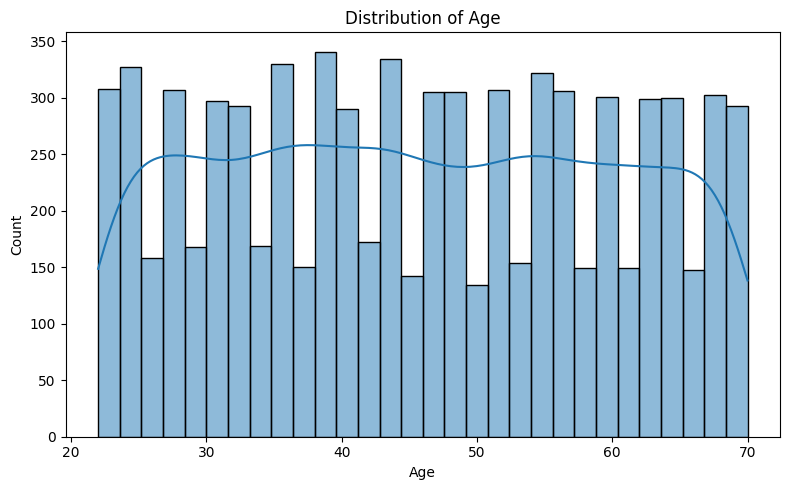

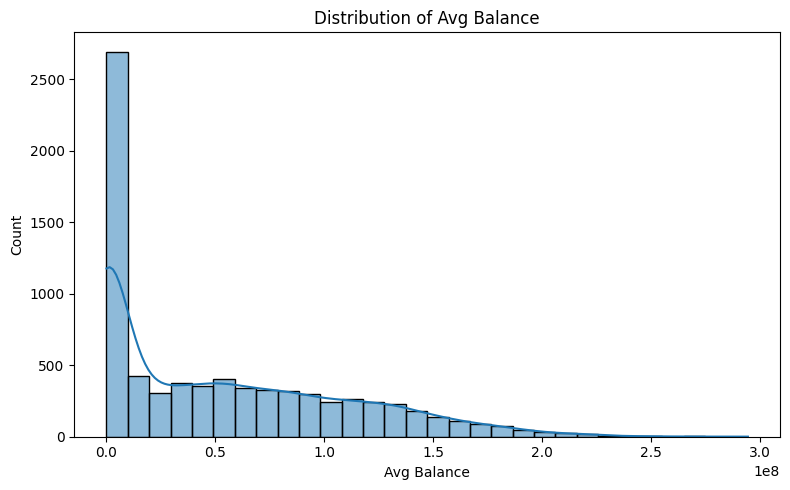

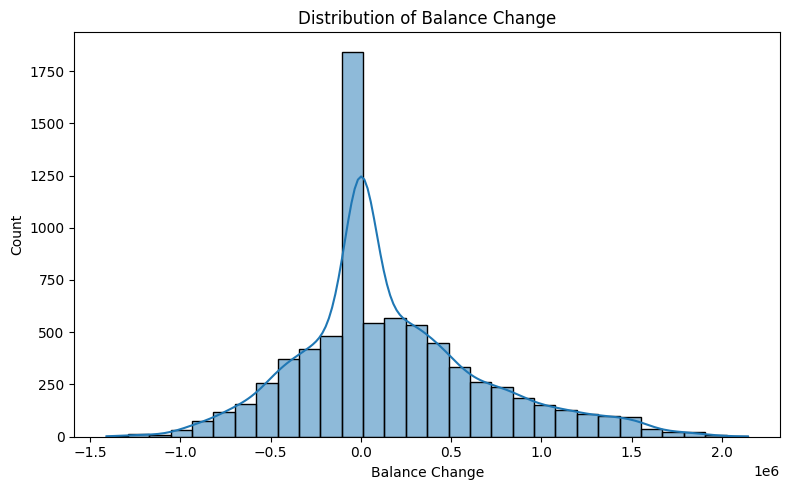

In [17]:
plot_histogram(df, "Age")
plot_histogram(df, "Avg Balance")
plot_histogram(df, "Balance Change")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_histogram(df, column, bins=30):
    fig, ax = plt.subplots(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=column,
        bins=bins,
        kde=True,
        ax=ax
    )

    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

def plot_boxplot(df, x, y):
    fig, ax = plt.subplots(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x=x,
        y=y,
        ax=ax
    )

    ax.set_title(f"{y} by {x}")

    plt.tight_layout()
    plt.show()

def plot_countplot(df, column):
    fig, ax = plt.subplots(figsize=(8,5))

    sns.countplot(
        data=df,
        x=column,
        ax=ax
    )

    ax.set_title(f"Distribution of {column}")

    plt.tight_layout()
    plt.show()

def unpaid_rate(df, groupby_col):
    result = (
        df.groupby(groupby_col)["Unpaid Tagging"]
          .mean()
          .mul(100)
          .sort_values(ascending=False)
          .reset_index(name="Unpaid Rate (%)")
    )

    return result

    unpaid_rate(df, "City")

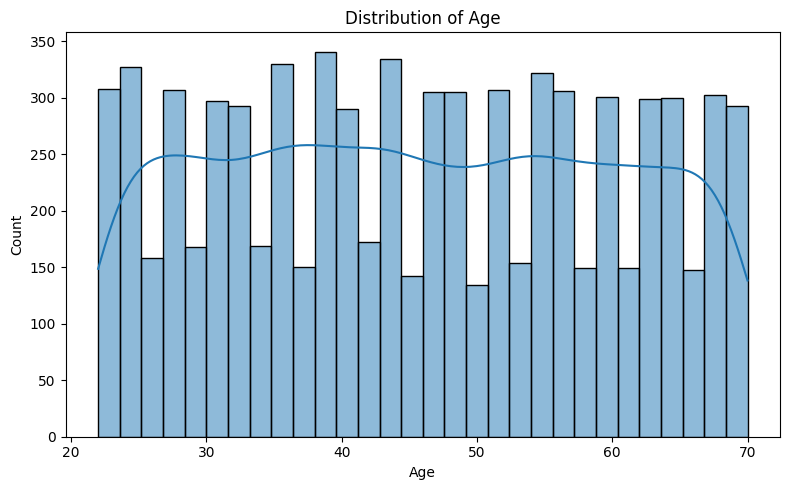

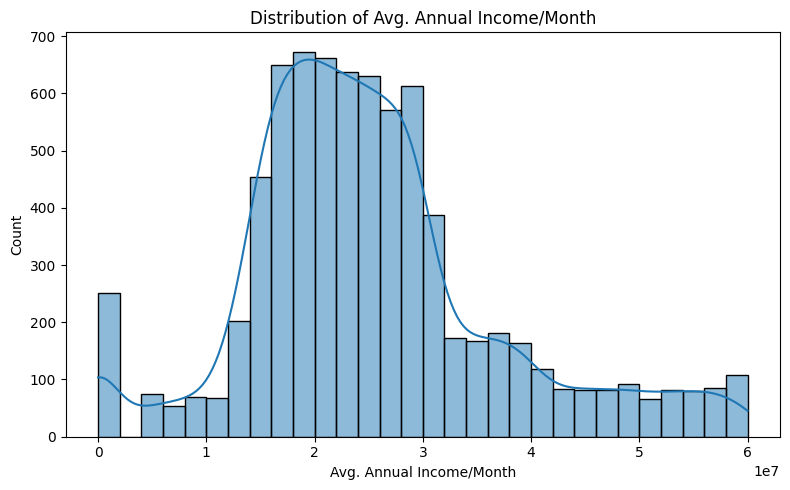

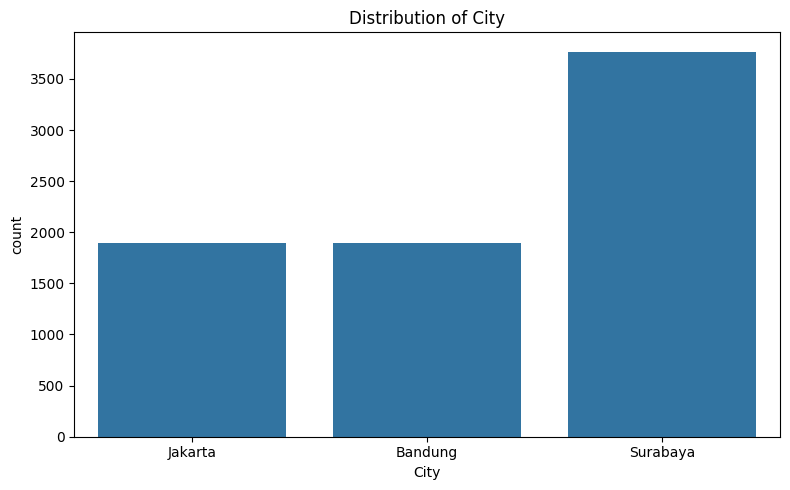

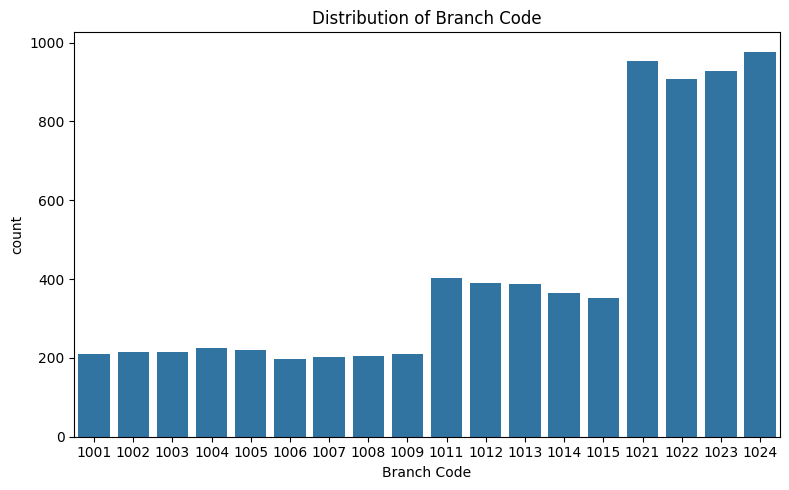

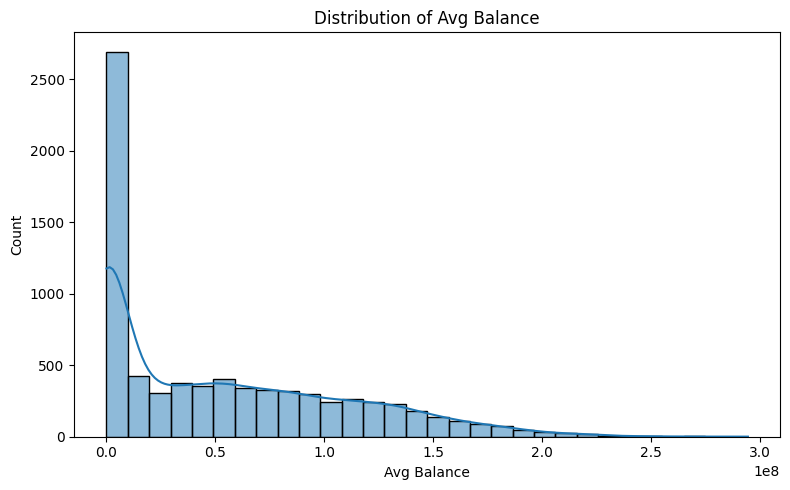

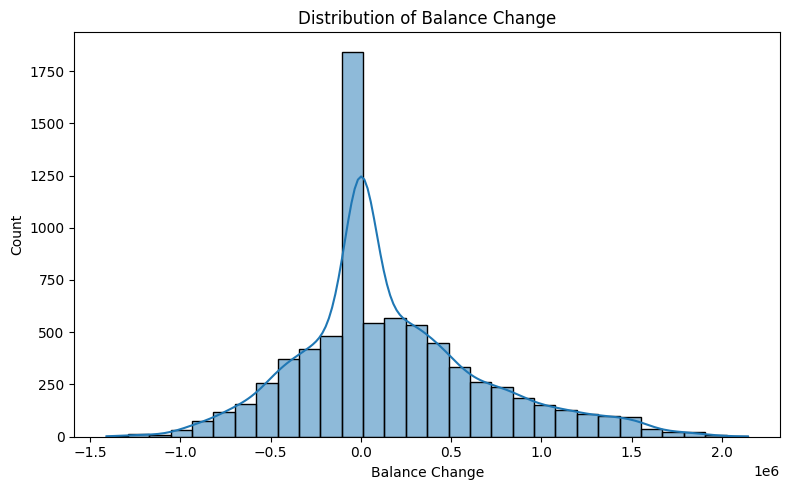

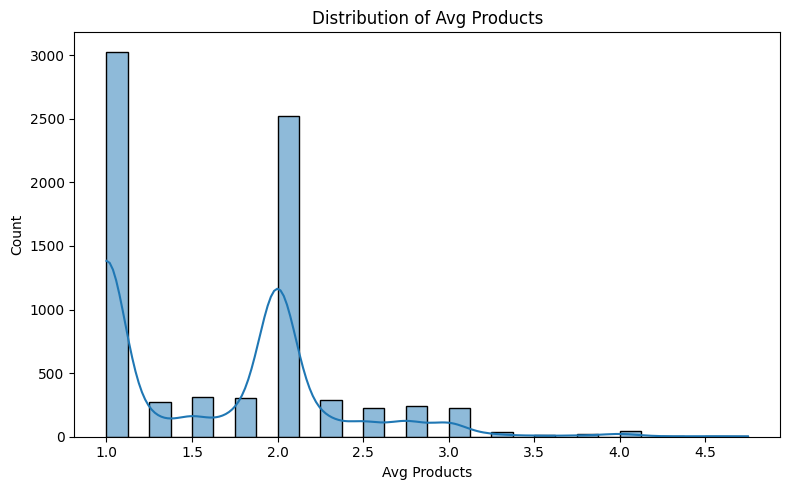

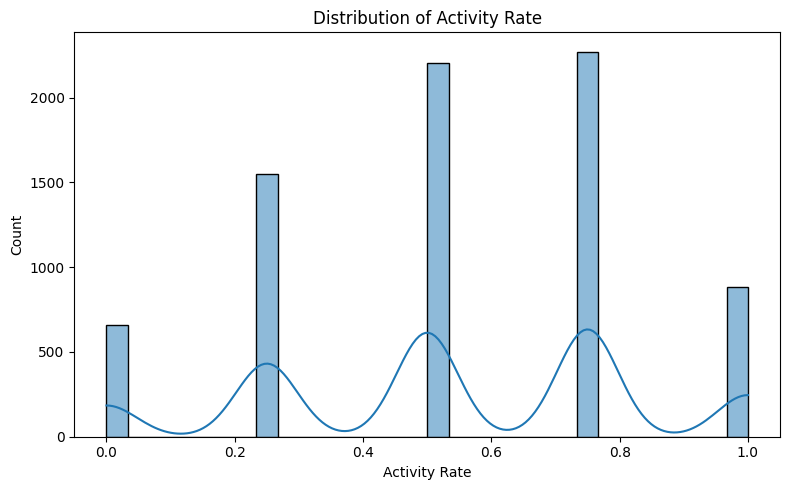

In [20]:
# Credit Risk Overview
df["Unpaid Tagging"].value_counts()
df["Unpaid Tagging"].value_counts(normalize=True) * 100

# Customer Age
plot_histogram(df, "Age")
df["Age"].describe()

# Income
plot_histogram(df, "Avg. Annual Income/Month")

# City
plot_countplot(df, "City")

# Branch
plot_countplot(df, "Branch Code")

# Average Balance
plot_histogram(df, "Avg Balance")

# Balance Change
plot_histogram(df, "Balance Change")

# Avg Products
plot_histogram(df, "Avg Products")

# Activity Rate
plot_histogram(df, "Activity Rate")

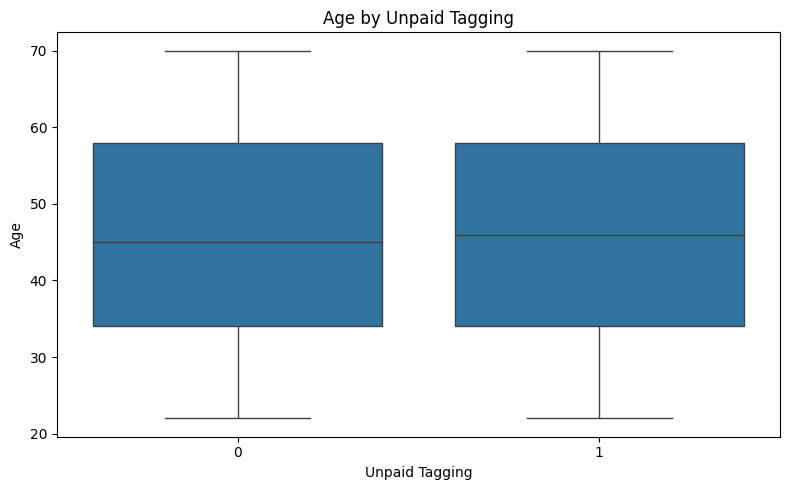

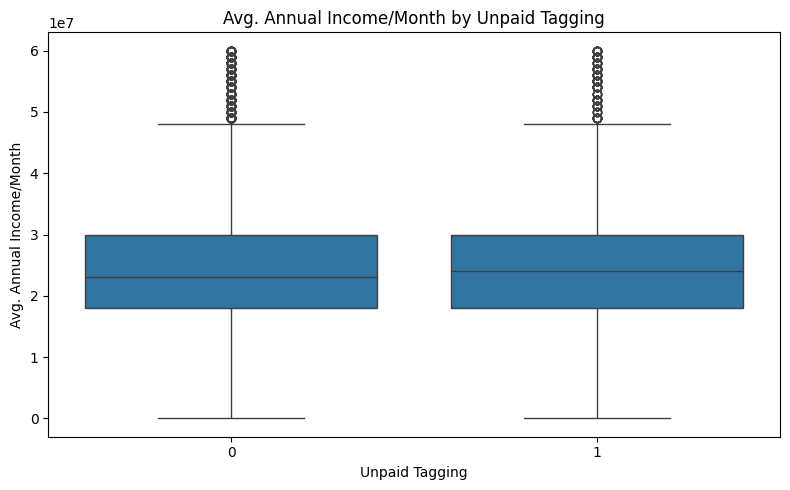

,City,Unpaid Rate (%)
0,Surabaya,27.42
1,Bandung,26.13
2,Jakarta,25.84


In [21]:
# Bivariate Analysis
# Age vs Unpaid
plot_boxplot(
    df,
    x="Unpaid Tagging",
    y="Age"
)

df.groupby("Unpaid Tagging")["Age"].describe()

# Income vs Unpaid
plot_boxplot(
    df,
    x="Unpaid Tagging",
    y="Avg. Annual Income/Month"
)

city_rate = unpaid_rate(df, "City")
city_rate

In [22]:
# Mutivariate
# Correlation
corr_cols = [
    "Age",
    "Avg. Annual Income/Month",
    "Avg Balance",
    "Balance Change",
    "Avg Products",
    "Activity Rate",
    "Unpaid Tagging"
]

corr = df[corr_cols].corr(numeric_only=True)
